<a href="https://colab.research.google.com/github/ailingomezromay/Grupo-4--TP-BigData-Burnout/blob/rama-vane/TP_Grupo%204_BigData_Burnout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP Final - Big Data y MLOps

Predicción de riesgo de burnout en empleados del sector tecnológico

# Grupo 4
Ailin Gomez Romay  
Carlos Lazzarino  
Victoria Reppucci  
Vanessa Vidal

#1. Introducción

# Objetivo del trabajo

El objetivo de este trabajo es desarrollar un modelo de Machine Learning capaz de predecir el riesgo de burnout en empleados del sector tecnológico, a partir de variables demográficas, laborales y relacionadas con la salud mental.

#Dataset

El dataset fue obtenido de Kaggle ( https://www.kaggle.com/datasets/suhanigupta04/employee-mental-health-and-burnout-dataset ).

Contiene aproximadamente 150.000 registros sintéticos de empleados del sector tecnológico, con 25 variables que incluyen información demográfica, condiciones laborales e indicadores de salud mental.

El volumen del dataset justifica el uso de PySpark como framework de procesamiento distribuido. Además, las variables disponibles tienen una interpretación intuitiva y relevante para el problema: horas trabajadas, nivel de estrés, calidad de sueño, entre otras.

#Problema a resolver

Se busca identificar qué empleados presentan mayor riesgo de burnout a partir de variables observables. Este tipo de análisis puede resultar de utilidad para áreas de Recursos Humanos y bienestar organizacional, ya que permite anticipar situaciones de riesgo y tomar decisiones preventivas de manera informada.

# 2. Librerías e imports

In [3]:
# Instalaciones necesarias
!pip install optuna mlflow shap fastapi uvicorn pydantic --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 11.3 MB/s eta 0:00:00


In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import mlflow
import mlflow.spark
import shap
from sklearn.linear_model import LogisticRegression as SklearnLR


# 3. Carga del dataset

En esta sección se carga el dataset seleccionado utilizando la funcionalidad de subida de archivos de Google Colab.

Una vez cargado, se realiza una inspección inicial para verificar la cantidad de registros y variables disponibles.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving tech_mental_health_burnout.csv to tech_mental_health_burnout.csv


In [6]:
data_path = 'tech_mental_health_burnout.csv'
df = pd.read_csv(data_path)

print(f'Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 150,000 filas x 25 columnas


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  object 
 2   job_role                 150000 non-null  object 
 3   experience_years         150000 non-null  float64
 4   company_size             150000 non-null  object 
 5   work_mode                150000 non-null  object 
 6   work_hours_per_week      150000 non-null  float64
 7   overtime_hours           150000 non-null  float64
 8   meetings_per_day         150000 non-null  float64
 9   deadlines_missed         150000 non-null  int64  
 10  job_satisfaction         150000 non-null  float64
 11  manager_support          150000 non-null  float64
 12  work_life_balance        150000 non-null  float64
 13  sleep_hours              150000 non-null  float64
 14  phys

#4.Exploración inicial del dataset (EDA)

El dataset contiene información sobre empleados del sector tecnológico, incluyendo variables demográficas, laborales y de salud mental. A partir de una primera inspección, se observa que la mayoría de las variables son numéricas, aunque también hay variables categóricas que deberán ser transformadas para el modelado.

# 4.1. Análisis de la variable objetivo

Se analiza la distribución de burnout_level para identificar posibles desbalances entre clases.



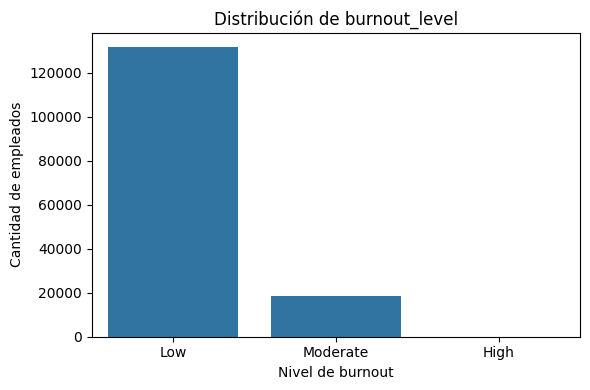

burnout_level
Low         87.7%
Moderate    12.2%
High         0.0%
Name: proportion, dtype: object


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='burnout_level', order=df['burnout_level'].value_counts().index)
plt.title('Distribución de burnout_level')
plt.xlabel('Nivel de burnout')
plt.ylabel('Cantidad de empleados')
plt.tight_layout()
plt.show()

print(df['burnout_level'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Se observa un fuerte desbalance de clases: la categoría Low concentra aproximadamente el 88% de los registros, mientras que High representa una fracción muy pequeña.

Este desbalance puede afectar negativamente el desempeño del modelo, ya que los algoritmos tienden a favorecer la clase mayoritaria. Por este motivo, se decide reformular el problema como clasificación binaria, agrupando Moderate y High en una única clase de riesgo (burnout_risk = 1).

# 4.2  Relación con variables clave y burnout



Relación entre estrés y burnout

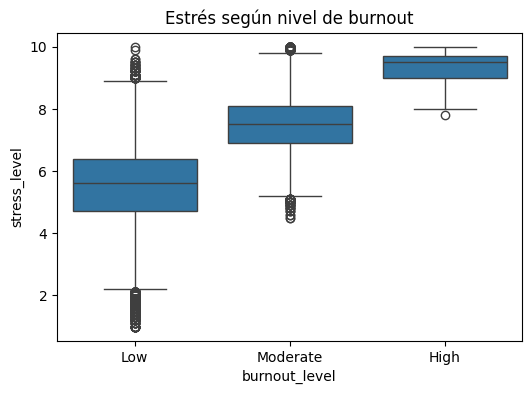

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="burnout_level", y="stress_level")
plt.title("Estrés según nivel de burnout")
plt.show()

Estrés: presenta la separación más pronunciada entre grupos, lo que sugiere que es el predictor individual más relevante.

Relación entre horas trabajadas y burnout

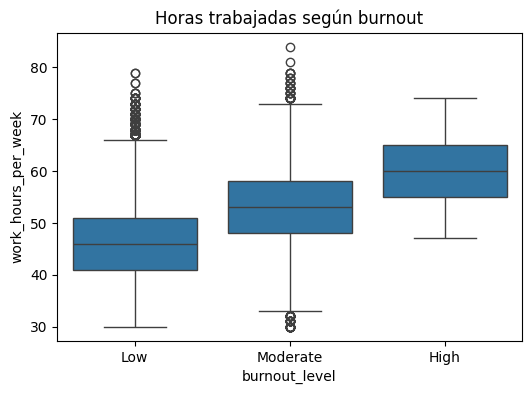

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="burnout_level", y="work_hours_per_week")
plt.title("Horas trabajadas según burnout")
plt.show()

Horas trabajadas: la tendencia es consistente (más horas, mayor burnout), aunque la diferencia entre grupos no es tan marcada.

Relación entre sueño y burnout

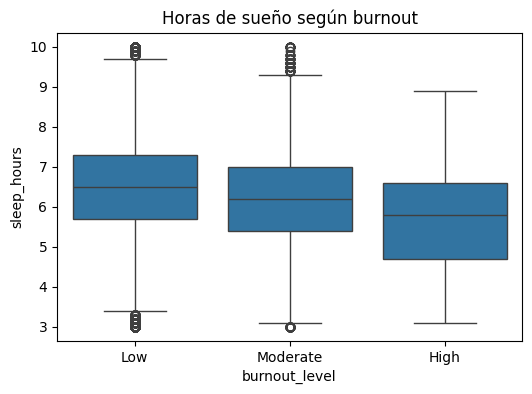

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="burnout_level", y="sleep_hours")
plt.title("Horas de sueño según burnout")
plt.show()

Horas de sueño: la diferencia entre Low y High es menor de lo esperado, aunque la dirección de la relación se mantiene.

# 4.3. Correlaciones

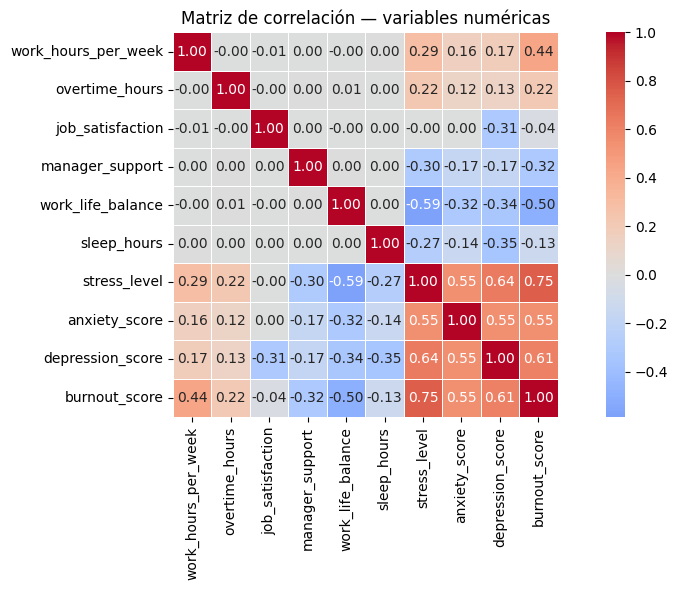

In [13]:
cols_corr = [
    'work_hours_per_week', 'overtime_hours', 'job_satisfaction',
    'manager_support', 'work_life_balance', 'sleep_hours',
    'stress_level', 'anxiety_score', 'depression_score', 'burnout_score'
]

corr = df[cols_corr].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()



Las variables de salud mental (stress_level, anxiety_score, depression_score) presentan alta correlación positiva con burnout_score. Variables como work_life_balance y sleep_hours muestran correlación negativa, comportándose como factores protectores.


#4.4 Cardinalidad de variables categóricas y valores nulos

In [14]:
print(f'Total de valores nulos: {df.isnull().sum().sum()}\n')

for col in ['gender', 'job_role', 'company_size', 'work_mode']:
    print(f'{col}: {df[col].nunique()} categorías — {df[col].unique().tolist()}')

Total de valores nulos: 0

gender: 3 categorías — ['Female', 'Male', 'Non-binary']
job_role: 8 categorías — ['Backend Developer', 'Frontend Developer', 'DevOps', 'Data Scientist', 'Software Engineer', 'Product Manager', 'QA Engineer', 'ML Engineer']
company_size: 4 categorías — ['Large', 'Mid-size', 'MNC', 'Startup']
work_mode: 3 categorías — ['Hybrid', 'Remote', 'Onsite']


## 5. Modelado con PySpark

En esta sección se construye el pipeline de procesamiento y se entrenan los modelos de clasificación base. El uso de pipelines garantiza la reproducibilidad y facilita la integración con MLflow.

#5.1 Inicialización de Spark

In [15]:
spark = SparkSession.builder \
    .appName("TP_BigData_Burnout") \
    .getOrCreate()

print(spark)

df_spark = spark.createDataFrame(df)
df_spark.printSchema()

root
 |-- age: long (nullable = true)
 |-- gender: string (nullable = true)
 |-- job_role: string (nullable = true)
 |-- experience_years: double (nullable = true)
 |-- company_size: string (nullable = true)
 |-- work_mode: string (nullable = true)
 |-- work_hours_per_week: double (nullable = true)
 |-- overtime_hours: double (nullable = true)
 |-- meetings_per_day: double (nullable = true)
 |-- deadlines_missed: long (nullable = true)
 |-- job_satisfaction: double (nullable = true)
 |-- manager_support: double (nullable = true)
 |-- work_life_balance: double (nullable = true)
 |-- sleep_hours: double (nullable = true)
 |-- physical_activity_days: long (nullable = true)
 |-- screen_time_hours: double (nullable = true)
 |-- caffeine_intake: long (nullable = true)
 |-- social_support_score: double (nullable = true)
 |-- has_therapy: long (nullable = true)
 |-- stress_level: double (nullable = true)
 |-- anxiety_score: double (nullable = true)
 |-- depression_score: double (nullable = tru

#5.2 Preparación de la variable objetivo

Se convierte el DataFrame de Pandas a Spark y se crea la variable binaria burnout_risk. Luego se eliminan burnout_level y burnout_score para evitar data leakage.

In [16]:
df_spark = df_spark.withColumn(
    "burnout_risk",
    F.when(F.col("burnout_level").isin("Moderate", "High"), 1).otherwise(0)
)

df_spark = df_spark.drop("burnout_level", "burnout_score")

df_spark.printSchema()

root
 |-- age: long (nullable = true)
 |-- gender: string (nullable = true)
 |-- job_role: string (nullable = true)
 |-- experience_years: double (nullable = true)
 |-- company_size: string (nullable = true)
 |-- work_mode: string (nullable = true)
 |-- work_hours_per_week: double (nullable = true)
 |-- overtime_hours: double (nullable = true)
 |-- meetings_per_day: double (nullable = true)
 |-- deadlines_missed: long (nullable = true)
 |-- job_satisfaction: double (nullable = true)
 |-- manager_support: double (nullable = true)
 |-- work_life_balance: double (nullable = true)
 |-- sleep_hours: double (nullable = true)
 |-- physical_activity_days: long (nullable = true)
 |-- screen_time_hours: double (nullable = true)
 |-- caffeine_intake: long (nullable = true)
 |-- social_support_score: double (nullable = true)
 |-- has_therapy: long (nullable = true)
 |-- stress_level: double (nullable = true)
 |-- anxiety_score: double (nullable = true)
 |-- depression_score: double (nullable = tru

#5.3 Pipeline de preprocesamiento

Limitación conocida: el StringIndexer se ajusta sobre el dataset completo antes del split, lo que podría introducir data leakage leve en categorías poco frecuentes. En un entorno productivo, el ajuste debería realizarse exclusivamente sobre el conjunto de entrenamiento.

In [17]:
categorical_cols = [
    "gender", "job_role", "company_size", "work_mode"
]

numeric_cols = [
    "age", "experience_years", "work_hours_per_week", "overtime_hours",
    "meetings_per_day", "deadlines_missed", "job_satisfaction",
    "manager_support", "work_life_balance", "sleep_hours",
    "physical_activity_days", "screen_time_hours", "caffeine_intake",
    "social_support_score", "has_therapy", "stress_level",
    "anxiety_score", "depression_score", "seeks_professional_help"
]

target_col = "burnout_risk"

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    for col in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=f"{col}_idx", outputCol=f"{col}_ohe")
    for col in categorical_cols
]

feature_cols = numeric_cols + [f"{col}_ohe" for col in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

train_df, test_df = df_spark.randomSplit([0.8, 0.2], seed=42)

print("Train:", train_df.count())
print("Test:", test_df.count())

Train: 119856
Test: 30144


#5.4 Entrenamiento de modelos base

In [18]:
# Regresión Logística
lr = LogisticRegression(featuresCol='features', labelCol='burnout_risk')
pipeline_lr = Pipeline(stages=indexers + encoders + [assembler, lr])
model_lr    = pipeline_lr.fit(train_df)
preds_lr    = model_lr.transform(test_df)

# Random Forest
rf = RandomForestClassifier(featuresCol='features', labelCol='burnout_risk',
                             numTrees=50, seed=42)
pipeline_rf = Pipeline(stages=indexers + encoders + [assembler, rf])
model_rf    = pipeline_rf.fit(train_df)
preds_rf    = model_rf.transform(test_df)

#5.5 Evaluación de modelos base

In [19]:
evaluator_auc = BinaryClassificationEvaluator(
    labelCol='burnout_risk', metricName='areaUnderROC')
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol='burnout_risk', metricName='f1')

auc_lr = evaluator_auc.evaluate(preds_lr)
f1_lr  = evaluator_f1.evaluate(preds_lr)
auc_rf = evaluator_auc.evaluate(preds_rf)
f1_rf  = evaluator_f1.evaluate(preds_rf)

print(f"{'Modelo':<25} {'AUC':>8} {'F1':>8}")
print('-' * 43)
print(f"{'Logistic Regression':<25} {auc_lr:>8.4f} {f1_lr:>8.4f}")
print(f"{'Random Forest':<25} {auc_rf:>8.4f} {f1_rf:>8.4f}")

Modelo                         AUC       F1
-------------------------------------------
Logistic Regression         0.9621   0.9293
Random Forest               0.9279   0.8968


La Regresión Logística obtuvo mejor AUC y F1. Se selecciona como modelo candidato por su mejor desempeño y mayor interpretabilidad. Estos resultados serán refinados mediante búsqueda de hiperparámetros en la sección siguiente.

#5.6 Matriz de confusión

Para complementar el AUC calculamos el F1-score (0.93) y la matriz de confusión. Esto es especialmente importante dado el desbalance: el F1 penaliza los falsos negativos, que en este contexto son los casos de burnout que el modelo no detecta.

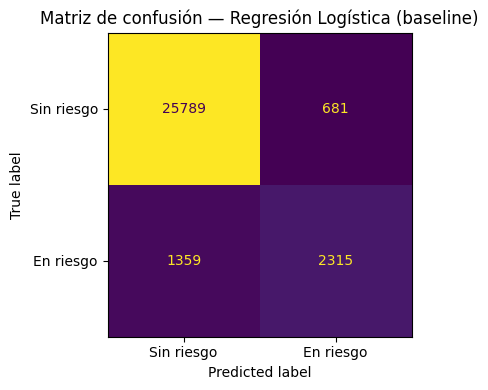

In [20]:
preds_pd = preds_lr.select('burnout_risk', 'prediction').toPandas()
cm       = confusion_matrix(preds_pd['burnout_risk'], preds_pd['prediction'])
disp     = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Sin riesgo', 'En riesgo'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title('Matriz de confusión — Regresión Logística (baseline)')
plt.tight_layout()
plt.show()

#5.7 Interpretabilidad con SHAP

Se utiliza SHAP con una Regresión Logística equivalente entrenada en scikit-learn sobre las variables numéricas, para analizar el impacto de cada variable en las predicciones.




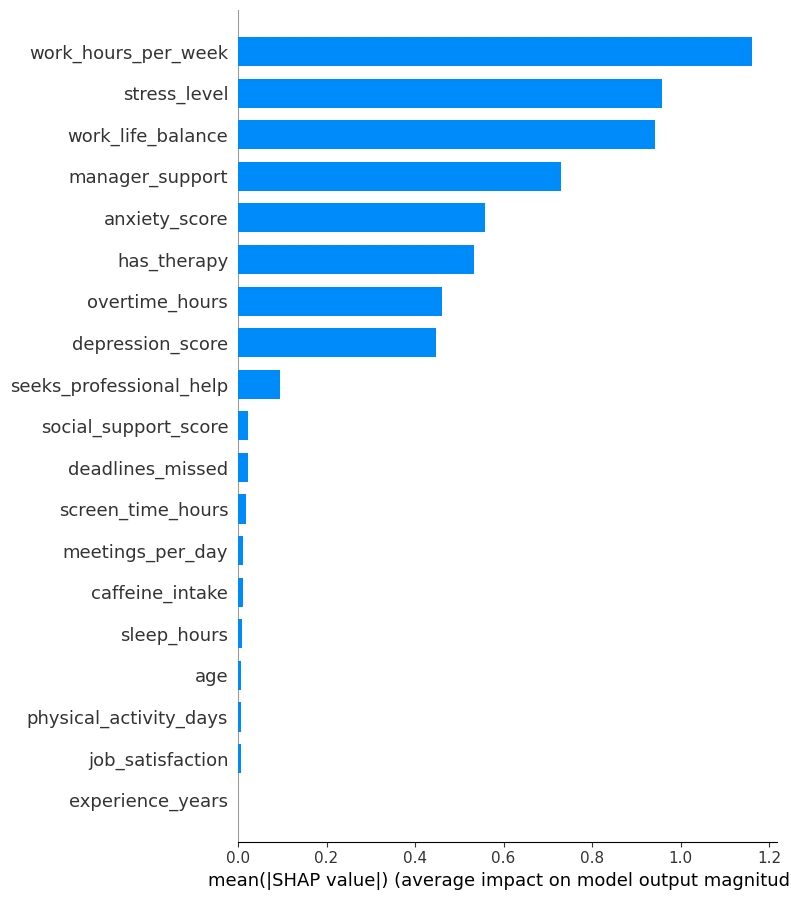

In [21]:
train_pd = train_df.select(numeric_cols + ['burnout_risk']).toPandas().dropna()
X_train  = train_pd[numeric_cols]
y_train  = train_pd['burnout_risk']

sk_model = SklearnLR(max_iter=1000)
sk_model.fit(X_train, y_train)

explainer   = shap.LinearExplainer(sk_model, X_train)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type='bar',
                  title='Importancia de variables — SHAP (Regresión Logística)')

Las variables con mayor impacto son stress_level, work_hours_per_week y work_life_balance, lo cual es consistente con el análisis exploratorio.

#6. MLflow

In [22]:
mlflow.set_experiment("TP_BigData_Burnout")

2026/04/03 17:32:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/03 17:32:52 INFO mlflow.store.db.utils: Updating database tables
2026/04/03 17:32:56 INFO mlflow.tracking.fluent: Experiment with name 'TP_BigData_Burnout' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1775237576086, experiment_id='1', last_update_time=1775237576086, lifecycle_stage='active', name='TP_BigData_Burnout', tags={}, workspace='default'>

Registrar Logistic

In [23]:

mlflow.end_run()

with mlflow.start_run(run_name="Logistic_Regression") as run_lr:
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("train_size", train_df.count())
    mlflow.log_metric("AUC", auc_lr)
    mlflow.log_metric("F1", f1_lr)


    mlflow.spark.log_model(model_lr, "model")
    run_id_lr = run_lr.info.run_id


model_uri = f"runs:/{run_id_lr}/model"
mlflow.register_model(model_uri, "Burnout_Model")

Successfully registered model 'Burnout_Model'.
Created version '1' of model 'Burnout_Model'.


<ModelVersion: aliases=[], creation_timestamp=1775237629465, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1775237629465, metrics=None, model_id=None, name='Burnout_Model', params=None, run_id='4f28b5d447844001b68f3fca087f8db0', run_link=None, source='/content/mlruns/1/4f28b5d447844001b68f3fca087f8db0/artifacts/model', status='READY', status_message=None, tags={}, user_id=None, version=1, workspace='default'>

Registrar Random Forest

In [24]:
with mlflow.start_run(run_name="Random_Forest"):
    mlflow.log_param("model", "Random Forest")
    mlflow.log_param("numTrees", 50)
    mlflow.log_param("train_size", train_df.count())
    mlflow.log_metric("AUC", auc_rf)
    mlflow.log_metric("F1", f1_rf)

## Registro de experimentos con MLflow

Usamos MLflow para registrar los dos modelos y poder comparar métricas desde la UI. Además de AUC logueamos también F1 y los parámetros principales de cada modelo.

#7.Búsqueda de hiperparámetros con Optuna + MLflow Tracking

En esta sección se optimizan los dos modelos elegidos del trabajo:
- **Logistic Regression**
- **Random Forest**

Para cada trial de Optuna se registran:
- hiperparámetros probados
- métricas de desempeño (**AUC** y **F1**)
- nombre del modelo

Todo queda guardado en **MLflow Tracking**, así que después se puede comparar fácilmente desde la UI.


In [25]:
!pip install optuna mlflow

In [26]:

evaluator_auc_optuna = BinaryClassificationEvaluator(
    labelCol="burnout_risk",
    metricName="areaUnderROC"
)

evaluator_f1_optuna = MulticlassClassificationEvaluator(
    labelCol="burnout_risk",
    predictionCol="prediction",
    metricName="f1"
)


In [27]:

def objective_lr(trial):
    reg_param = trial.suggest_float("regParam", 1e-4, 1.0, log=True)
    elastic_net_param = trial.suggest_float("elasticNetParam", 0.0, 1.0)
    max_iter = trial.suggest_int("maxIter", 50, 300)
    threshold = trial.suggest_float("threshold", 0.3, 0.7)

    lr_opt = LogisticRegression(
        featuresCol="features",
        labelCol="burnout_risk",
        regParam=reg_param,
        elasticNetParam=elastic_net_param,
        maxIter=max_iter,
        threshold=threshold
    )

    pipeline_lr_opt = Pipeline(stages=indexers + encoders + [assembler, lr_opt])

    with mlflow.start_run(run_name=f"optuna_lr_trial_{trial.number}", nested=True):
        model_lr_opt = pipeline_lr_opt.fit(train_df)
        predictions_lr_opt = model_lr_opt.transform(test_df)

        auc = evaluator_auc_optuna.evaluate(predictions_lr_opt)
        f1 = evaluator_f1_optuna.evaluate(predictions_lr_opt)

        mlflow.log_param("model", "Logistic Regression")
        mlflow.log_param("trial_number", trial.number)
        mlflow.log_params({
            "regParam": reg_param,
            "elasticNetParam": elastic_net_param,
            "maxIter": max_iter,
            "threshold": threshold
        })
        mlflow.log_metric("AUC", auc)
        mlflow.log_metric("F1", f1)

    return auc


In [28]:

def objective_rf(trial):
    num_trees = trial.suggest_int("numTrees", 50, 300, step=25)
    max_depth = trial.suggest_int("maxDepth", 3, 15)
    max_bins = trial.suggest_int("maxBins", 32, 128, step=16)
    min_instances_per_node = trial.suggest_int("minInstancesPerNode", 1, 10)
    subsampling_rate = trial.suggest_float("subsamplingRate", 0.6, 1.0)

    rf_opt = RandomForestClassifier(
        featuresCol="features",
        labelCol="burnout_risk",
        numTrees=num_trees,
        maxDepth=max_depth,
        maxBins=max_bins,
        minInstancesPerNode=min_instances_per_node,
        subsamplingRate=subsampling_rate,
        seed=42
    )

    pipeline_rf_opt = Pipeline(stages=indexers + encoders + [assembler, rf_opt])

    with mlflow.start_run(run_name=f"optuna_rf_trial_{trial.number}", nested=True):
        model_rf_opt = pipeline_rf_opt.fit(train_df)
        predictions_rf_opt = model_rf_opt.transform(test_df)

        auc = evaluator_auc_optuna.evaluate(predictions_rf_opt)
        f1 = evaluator_f1_optuna.evaluate(predictions_rf_opt)

        mlflow.log_param("model", "Random Forest")
        mlflow.log_param("trial_number", trial.number)
        mlflow.log_params({
            "numTrees": num_trees,
            "maxDepth": max_depth,
            "maxBins": max_bins,
            "minInstancesPerNode": min_instances_per_node,
            "subsamplingRate": subsampling_rate
        })
        mlflow.log_metric("AUC", auc)
        mlflow.log_metric("F1", f1)

    return auc


In [29]:

N_TRIALS = 15


In [34]:

!pip install -q optuna mlflow

import optuna
import mlflow
import mlflow.spark

In [ ]:

mlflow.end_run()

with mlflow.start_run(run_name="Optuna_Logistic_Regression_Search"):
    study_lr = optuna.create_study(direction="maximize", study_name="study_lr")
    study_lr.optimize(objective_lr, n_trials=N_TRIALS)

print("Mejor AUC Logistic Regression:", study_lr.best_value)
print("Mejores hiperparámetros LR:", study_lr.best_params)


[I 2026-04-03 17:42:55,088] A new study created in memory with name: study_lr
[I 2026-04-03 17:43:41,157] Trial 0 finished with value: 0.9621322111760955 and parameters: {'regParam': 0.000499345928326826, 'elasticNetParam': 0.3801902730118104, 'maxIter': 152, 'threshold': 0.6224098653961976}. Best is trial 0 with value: 0.9621322111760955.
[I 2026-04-03 17:44:04,044] Trial 1 finished with value: 0.5 and parameters: {'regParam': 0.6453945446789157, 'elasticNetParam': 0.8646325129135174, 'maxIter': 94, 'threshold': 0.3302663505159768}. Best is trial 0 with value: 0.9621322111760955.
[I 2026-04-03 17:44:44,724] Trial 2 finished with value: 0.9311388813539594 and parameters: {'regParam': 0.16168227026866933, 'elasticNetParam': 0.453448976839258, 'maxIter': 134, 'threshold': 0.32134254255450306}. Best is trial 0 with value: 0.9621322111760955.
[I 2026-04-03 17:45:14,706] Trial 3 finished with value: 0.9621798714622128 and parameters: {'regParam': 0.0005744341294337796, 'elasticNetParam': 0.

In [31]:

mlflow.end_run()

with mlflow.start_run(run_name="Optuna_Random_Forest_Search"):
    study_rf = optuna.create_study(direction="maximize", study_name="study_rf")
    study_rf.optimize(objective_rf, n_trials=N_TRIALS)

print("Mejor AUC Random Forest:", study_rf.best_value)
print("Mejores hiperparámetros RF:", study_rf.best_params)


NameError: name 'optuna' is not defined

In [ ]:

best_models_optuna = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "best_auc": study_lr.best_value,
        **study_lr.best_params
    },
    {
        "model": "Random Forest",
        "best_auc": study_rf.best_value,
        **study_rf.best_params
    }
])

best_models_optuna



Con esta tabla se puede justificar la elección del modelo final a partir de la búsqueda de hiperparámetros. Además, cada combinación probada queda registrada en MLflow como un experimento hijo.


In [32]:

if best_model_name_optuna == "Logistic Regression":
    best_lr = LogisticRegression(
        featuresCol="features",
        labelCol="burnout_risk",
        regParam=study_lr.best_params["regParam"],
        elasticNetParam=study_lr.best_params["elasticNetParam"],
        maxIter=study_lr.best_params["maxIter"],
        threshold=study_lr.best_params["threshold"]
    )

    final_pipeline_optuna = Pipeline(stages=indexers + encoders + [assembler, best_lr])

else:
    best_rf = RandomForestClassifier(
        featuresCol="features",
        labelCol="burnout_risk",
        numTrees=study_rf.best_params["numTrees"],
        maxDepth=study_rf.best_params["maxDepth"],
        maxBins=study_rf.best_params["maxBins"],
        minInstancesPerNode=study_rf.best_params["minInstancesPerNode"],
        subsamplingRate=study_rf.best_params["subsamplingRate"],
        seed=42
    )

    final_pipeline_optuna = Pipeline(stages=indexers + encoders + [assembler, best_rf])


NameError: name 'best_model_name_optuna' is not defined

In [ ]:

mlflow.end_run()

with mlflow.start_run(run_name="Best_Model_After_Optuna"):
    final_model_optuna = final_pipeline_optuna.fit(train_df)
    final_predictions_optuna = final_model_optuna.transform(test_df)

    final_auc_optuna = evaluator_auc_optuna.evaluate(final_predictions_optuna)
    final_f1_optuna = evaluator_f1_optuna.evaluate(final_predictions_optuna)

    mlflow.log_param("best_model_after_optuna", best_model_name_optuna)
    mlflow.log_metric("AUC", final_auc_optuna)
    mlflow.log_metric("F1", final_f1_optuna)
    mlflow.spark.log_model(final_model_optuna, "model")

print("AUC final luego de Optuna:", final_auc_optuna)
print("F1 final luego de Optuna:", final_f1_optuna)


In [ ]:

df_trials_lr = study_lr.trials_dataframe()
df_trials_lr["model"] = "Logistic Regression"

df_trials_rf = study_rf.trials_dataframe()
df_trials_rf["model"] = "Random Forest"

df_trials_optuna = pd.concat([df_trials_lr, df_trials_rf], ignore_index=True)
df_trials_optuna = df_trials_optuna.sort_values(["model", "value"], ascending=[True, False])

df_trials_optuna.head(20)


# SHAP - Interpretabilidad del modelo final

In [ ]:
# Convertir a pandas para usar SHAP
train_pd = train_df.select(numeric_cols + ["burnout_risk"]).toPandas().dropna()
X_train = train_pd[numeric_cols]
y_train = train_pd["burnout_risk"]

sk_model = SklearnLR(max_iter=1000)
sk_model.fit(X_train, y_train)

explainer = shap.LinearExplainer(sk_model, X_train)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar",
                  title="Importancia de variables - SHAP")

Usamos SHAP para analizar qué variables tienen más peso en el modelo. Esto valida la elección de Logistic Regression: no solo tiene mejor AUC sino que podemos explicar sus predicciones, lo cual es importante si el área de RRHH va a usar esto para tomar decisiones.

Según el gráfico SHAP, las variables con mayor impacto fueron stress_level, work_hours_per_week y work_life_balance, lo cual es consistente con lo observado en el EDA.

# Ejemplo de inferencia

In [ ]:
predictions_lr.select("burnout_risk", "prediction", "probability").show(10, truncate=False)

ejemplo = spark.createDataFrame([{
    "age": 32, "gender": "Male", "job_role": "Engineer",
    "company_size": "Large", "work_mode": "Remote",
    "experience_years": 5, "work_hours_per_week": 50,
    "overtime_hours": 10, "meetings_per_day": 4,
    "deadlines_missed": 2, "job_satisfaction": 3,
    "manager_support": 2, "work_life_balance": 2,
    "sleep_hours": 5, "physical_activity_days": 1,
    "screen_time_hours": 9, "caffeine_intake": 4,
    "social_support_score": 3, "has_therapy": 0,
    "stress_level": 8, "anxiety_score": 7,
    "depression_score": 6, "seeks_professional_help": 0
}])

prediccion = model_lr.transform(ejemplo)
prediccion.select("prediction", "probability").show(truncate=False)

El modelo predijo burnout_risk = 1 (en riesgo) con una probabilidad del 99%. Para un perfil con 50 horas semanales, estrés 8/10 y poco descanso, el resultado tiene sentido y muestra que el modelo discrimina bien en casos extremos. Así es como podría usarse en la práctica: RRHH ingresa el perfil de un empleado y obtiene una señal de alerta antes de que el problema escale.

## Conclusiones finales

En este trabajo se desarrolló un modelo de Machine Learning para predecir el riesgo de burnout en empleados del sector tecnológico.

El análisis exploratorio permitió identificar variables relevantes como el nivel de estrés, las horas trabajadas y las horas de sueño, las cuales mostraron una relación significativa con el burnout.

Se implementó un pipeline de procesamiento utilizando PySpark, y se entrenaron modelos de clasificación evaluados mediante la métrica AUC. Además, se utilizó MLflow para registrar los experimentos y asegurar la reproducibilidad del proceso.

A partir de la comparación de modelos, se seleccionó Logistic Regression como modelo final debido a su mejor desempeño y mayor interpretabilidad.

Lo que más nos costó fue entender el efecto del desbalance de clases en las métricas. Al principio el AUC parecía excelente, pero al revisar las predicciones individuales notamos que el modelo tendía a predecir siempre la clase mayoritaria. Eso nos hizo replantear cómo interpretar los resultados. Para una próxima versión aplicaríamos balanceo de clases y probablemente ajustaríamos el threshold de decisión en lugar de usar 0.5 por defecto.